<a href="https://colab.research.google.com/github/NaydelinAidee/Procesos-Estocasticos/blob/main/descomposicioncanonicanay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En una Notebook de Jupyter realice lo siguiente:

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.
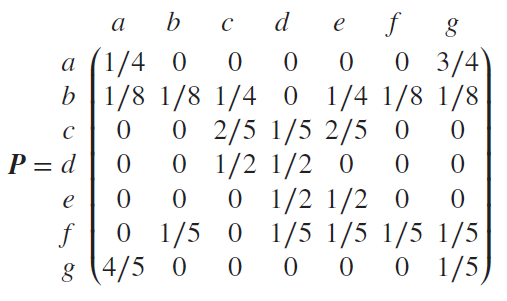

* Define la Matriz: Primero Creamos dos representaciones de la matriz P.
Una con valores flotantes (P_vals) para evaluar qué probabilidades son mayores a 0, y otra de texto (P_str) para poder imprimir en pantalla las fracciones de la manera exacta en la que vienen en tu imagen.

* Genera el Grafo (nx.DiGraph): Creamos un grafo dirigido y, por medio de ciclos for, evalúamos cada renglón y columna. Si la probabilidad es mayor a 0, crea una ruta entre el estado de origen y el estado de destino.

* Visualización (plt.show()):lo vemos graficamente.

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# estados y la matriz de transición P
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

# Matriz P usando valores decimales para los cálculos (opcional, pero útil para simulaciones)
P_vals = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0  ],
    [0,   0,   1/2, 1/2, 0,   0,   0  ],
    [0,   0,   0,   1/2, 1/2, 0,   0  ],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

# Matriz en formato texto para mostrar las fracciones exactas en el grafo
P_str = [
    ['1/4', '0',   '0',   '0',   '0',   '0',   '3/4'],
    ['1/8', '1/8', '1/4', '0',   '1/4', '1/8', '1/8'],
    ['0',   '0',   '2/5', '1/5', '2/5', '0',   '0'  ],
    ['0',   '0',   '1/2', '1/2', '0',   '0',   '0'  ],
    ['0',   '0',   '0',   '1/2', '1/2', '0',   '0'  ],
    ['0',   '1/5', '0',   '1/5', '1/5', '1/5', '1/5'],
    ['4/5', '0',   '0',   '0',   '0',   '0',   '1/5']
]

# Mostrar la matriz P
print("Matriz de Transición P:")
print(np.array(P_str))

Matriz de Transición P:
[['1/4' '0' '0' '0' '0' '0' '3/4']
 ['1/8' '1/8' '1/4' '0' '1/4' '1/8' '1/8']
 ['0' '0' '2/5' '1/5' '2/5' '0' '0']
 ['0' '0' '1/2' '1/2' '0' '0' '0']
 ['0' '0' '0' '1/2' '1/2' '0' '0']
 ['0' '1/5' '0' '1/5' '1/5' '1/5' '1/5']
 ['4/5' '0' '0' '0' '0' '0' '1/5']]


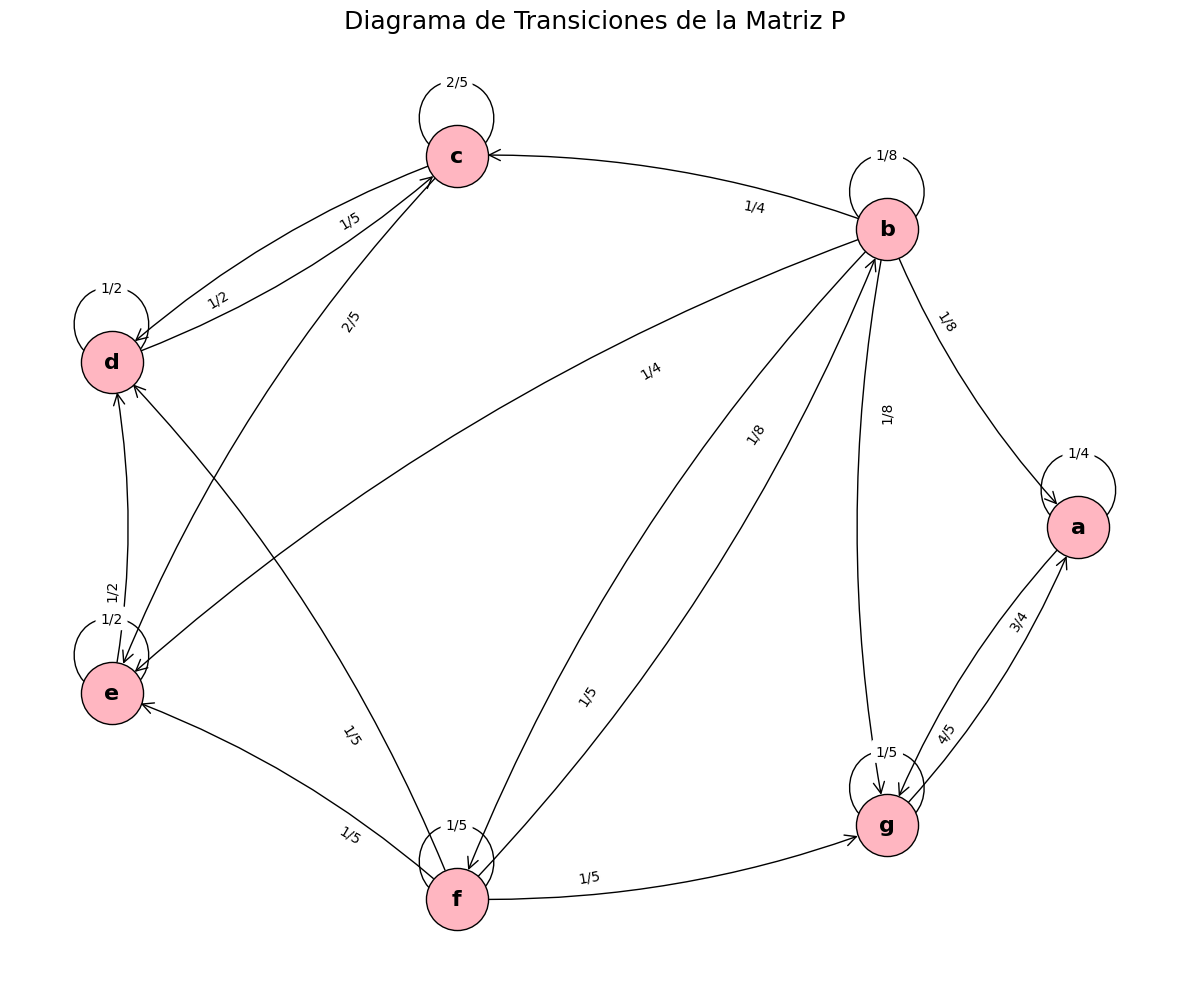

In [20]:
# grafo dirigido para el diagrama de transiciones
G = nx.DiGraph()
G.add_nodes_from(estados)

for i in range(len(estados)):
    for j in range(len(estados)):
        if P_vals[i, j] > 0:
            G.add_edge(estados[i], estados[j], weight=P_str[i][j])

#diagrama
plt.figure(figsize=(12, 10))
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightpink', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

#Flechas
nx.draw_networkx_edges(G, pos, node_size=2000, arrowstyle='->', arrowsize=20,
                       connectionstyle='arc3,rad=0.1')

#etiquetas
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10,
                             label_pos=0.3, font_color='black')

plt.title("Diagrama de Transiciones de la Matriz P", fontsize=18)
plt.axis('off') # Ocultar ejes
plt.tight_layout()
plt.show()

2. Determine si la matriz tiene o no distribución límite.

* Análisis de las Clases de Comunicación

Si observamos las transiciones de un estado a otro, podemos agrupar los estados de la siguiente manera:

* Clase 1 {a,g}:

-Desde a solo se puede ir a a o g.

-Desde g solo se puede ir a a o g.

Esta es una clase cerrada y recurrente ya que una vez que se entra a {a,g}, nunca puedes salir.

* Clase 2 {c,d,e}:

-Desde c puedes ir a c,d,e.

-Desde d puedes ir a c,d.

-Desde e puedes ir a d,e.

Cualquier transición desde estos tres nodos se queda entre ellos mismos. Esta es otra clase cerrada y recurrente.

* Estados Transitorios {b,f}:

El estado b tiene probabilidades de saltar hacia a y g (Clase 1), y hacia c y e (Clase 2).

El estado f también tiene probabilidades de saltar hacia otras clases.

Como eventualmente saldrán de su estado para caer en una de las clases cerradas (y ya no podrán regresar a b o f), se les llama estados transitorios.

2. Conclusión sobre la Distribución Límite

Para que una cadena de Markov tenga una distribución límite única (es decir, que a largo plazo las probabilidades se estabilicen en un mismo vector sin importar en qué estado  se comenzó), la cadena debe ser irreducible. Esto significa que debe existir una sola clase de comunicación que abarque todos los estados.

Como nuestra matriz P tiene dos clases cerradas distintas ({a,g} y {c,d,e}), la cadena es reducible.

El comportamiento a largo plazo de esta matriz depende completamente del estado inicial:

Si comenzamos en a o g, el sistema se estabilizará en las probabilidades internas de la Clase 1.

Si comenzamos  en c,d, o e, el sistema se estabilizará en las probabilidades internas de la Clase 2.

Si comenzamos  en b o f, el resultado final dependerá de la probabilidad de ser "absorbido" por la Clase 1 frente a la Clase 2.

En resumen matemático: El límite lim
n→∞
​
 P
n
  existe (porque los estados son aperiódicos, notar los valores en la diagonal principal como 1/4 y 2/5), pero las filas de la matriz resultante no serán idénticas. Por lo tanto, carece de una distribución límite global y única.

In [21]:
import numpy as np
import networkx as nx

# Definir nuevamente los estados y la matriz P_vals por si se ejecuta en una celda aislada
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
P_vals = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0  ],
    [0,   0,   1/2, 1/2, 0,   0,   0  ],
    [0,   0,   0,   1/2, 1/2, 0,   0  ],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

print("Clases de comunicación")
#grafo
G = nx.DiGraph()
G.add_nodes_from(estados)
for i in range(len(estados)):
    for j in range(len(estados)):
        if P_vals[i, j] > 0:
            G.add_edge(estados[i], estados[j])

# nodos que se comunican entre sí
clases_comunicacion = list(nx.strongly_connected_components(G))

print("Grupos de estados que se comunican entre sí:")
for i, clase in enumerate(clases_comunicacion):
    print(f"Clase {i+1}: {clase}")

Clases de comunicación
Grupos de estados que se comunican entre sí:
Clase 1: {'g', 'a'}
Clase 2: {'d', 'e', 'c'}
Clase 3: {'f', 'b'}


In [22]:
print("Limite a largo plazo ")
# Elevamos la matriz a una potencia grande para simular el comportamiento a largo plazo
n = 100
P_n = np.linalg.matrix_power(P_vals, n)
np.set_printoptions(precision=4, suppress=True)

print(f"Matriz P elevada a la potencia {n} (P^{n}):")
print(P_n)

# Lógica para verificar si todas las filas son iguales
# Comparamos todas las filas con la primera fila
filas_iguales = np.allclose(P_n, P_n[0])

Limite a largo plazo 
Matriz P elevada a la potencia 100 (P^100):
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]


In [23]:
print("Conclusion")
if filas_iguales:
    print("Todas las filas son iguales. La matriz SÍ tiene una distribución límite única.")
else:
    print("Las filas NO son idénticas. La matriz NO tiene una distribución límite global.")
    print("El estado estable depende enteramente del estado en el que se inicie (la fila).")

Conclusion
Las filas NO son idénticas. La matriz NO tiene una distribución límite global.
El estado estable depende enteramente del estado en el que se inicie (la fila).


3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

El proceso consta de:

* Descomposición Canónica: Reordenar la matriz separando las clases recurrentes ($C_1=\{a,g\}$ y $C_2=\{c,d,e\}$) y los estados transitorios ($T=\{b,f\}$).
    
* Distribuciones límite de las submatrices: Calcular los vectores estacionarios ($\pi_1$ y $\pi_2$) para las clases cerradas mediante el cálculo de sus vectores propios.
    
 * Límite de la potencia $n$-ésima ($P^\infty$): Calcular la matriz fundamental para obtener las probabilidades de absorción de los estados transitorios hacia las clases recurrentes, y con ello, armar la matriz límite total.

In [24]:
# Definir la matriz original (como flotantes)
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0  ],
    [0,   0,   1/2, 1/2, 0,   0,   0  ],
    [0,   0,   0,   1/2, 1/2, 0,   0  ],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

# DESCOMPOSICIÓN CANÓNICA
# orden: Clase 1 {a, g}, Clase 2 {c, d, e}, Transitorios {b, f}
nuevo_orden_idx = [0, 6, 2, 3, 4, 1, 5]
estados_can = [estados[i] for i in nuevo_orden_idx]

# Reordenar filas y luego columnas
P_can = P[nuevo_orden_idx, :][:, nuevo_orden_idx]

print("---Matriz en forma canónica ---")
print(f"Orden de los estados: {estados_can}")
np.set_printoptions(precision=4, suppress=True)
print(P_can)

---Matriz en forma canónica ---
Orden de los estados: ['a', 'g', 'c', 'd', 'e', 'b', 'f']
[[0.25  0.75  0.    0.    0.    0.    0.   ]
 [0.8   0.2   0.    0.    0.    0.    0.   ]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]]


In [25]:
# DISTRIBUCIONES LÍMITE DE LAS SUBMATRICES
P1 = P_can[0:2, 0:2] # {a, g}
P2 = P_can[2:5, 2:5] # {c, d, e}

# (pi * P = pi)
def calcular_distribucion_limite(sub_P):
    valores, vectores = np.linalg.eig(sub_P.T)
    idx = np.argmin(np.abs(valores - 1.0))
    pi = np.real(vectores[:, idx])
    return pi / np.sum(pi) # Normalizar para que sume 1
pi_1 = calcular_distribucion_limite(P1)
pi_2 = calcular_distribucion_limite(P2)

print("DISTRIBUCIONES LÍMITE DE LAS SUBMATRICES ")
print(f"Distribución límite pi_1 para la Clase 1 {{a, g}}:\n {pi_1}")
print(f"Distribución límite pi_2 para la Clase 2 {{c, d, e}}:\n {pi_2}")


DISTRIBUCIONES LÍMITE DE LAS SUBMATRICES 
Distribución límite pi_1 para la Clase 1 {a, g}:
 [0.5161 0.4839]
Distribución límite pi_2 para la Clase 2 {c, d, e}:
 [0.3333 0.4    0.2667]


In [26]:
# (P^infinito)
# Extraer matrices Q (Transitorio a Transitorio) y R (Transitorio a Recurrente)
Q = P_can[5:7, 5:7]
R = P_can[5:7, 0:5]

# N = (I - Q)^-1
I = np.eye(len(Q))
N = np.linalg.inv(I - Q)

# U = N * R
U = np.dot(N, R)

# Probabilidad de terminar en C1 o C2 partiendo de {b, f}
prob_absorcion_C1 = np.sum(U[:, 0:2], axis=1) # Suma de columnas de a y g
prob_absorcion_C2 = np.sum(U[:, 2:5], axis=1) # Suma de columnas de c, d, e

# Construir P_infinito_canónica
P_inf_can = np.zeros_like(P_can)

# Filas de C1: Son exactamente pi_1
P_inf_can[0:2, 0:2] = [pi_1, pi_1]

# Filas de C2: Son exactamente pi_2
P_inf_can[2:5, 2:5] = [pi_2, pi_2, pi_2]

# Filas de Transitorios: Combinación lineal de pi_1 y pi_2 según su probabilidad de absorción
for i in range(2): # 2 estados transitorios
    P_inf_can[5+i, 0:2] = prob_absorcion_C1[i] * pi_1
    P_inf_can[5+i, 2:5] = prob_absorcion_C2[i] * pi_2

# Mostrar P_infinito_canónica
print(P_inf_can)

print("Conclusiones")
print("Como se puede observar en la matriz P^∞:")
print("- Si el sistema inicia en {a, g} (filas 1 y 2), la distribución a largo plazo es exactamente pi_1.")
print("- Si el sistema inicia en {c, d, e} (filas 3, 4 y 5), la distribución a largo plazo es exactamente pi_2.")
print("- Si el sistema inicia en los estados transitorios {b, f} (filas 6 y 7), la distribución final no es una u otra pura, "
      "sino una suma ponderada (combinación lineal) de pi_1 y pi_2, multiplicada por la probabilidad de ser absorbidos por dicha clase.")

[[0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]]
Conclusiones
Como se puede observar en la matriz P^∞:
- Si el sistema inicia en {a, g} (filas 1 y 2), la distribución a largo plazo es exactamente pi_1.
- Si el sistema inicia en {c, d, e} (filas 3, 4 y 5), la distribución a largo plazo es exactamente pi_2.
- Si el sistema inicia en los estados transitorios {b, f} (filas 6 y 7), la distribución final no es una u otra pura, sino una suma ponderada (combinación lineal) de pi_1 y pi_2, multiplicada por la probabilidad de ser absorbidos por dicha clase.



* Matriz Canónica:El código reordena la matriz en bloques. En la esquina superior izquierda quedan matrices estocásticas independientes ($P_1$ y $P_2$), en la esquina inferior derecha la matriz $Q$ (transiciones entre estados transitorios) y a su izquierda la matriz $R$ (rutas de escape de los transitorios a las clases recurrentes).
    
* Límite de la submatriz: Al calcular $\pi_1 P_1 = \pi_1$ obtenemos $\pi_1 = \left[\frac{16}{31}, \frac{15}{31}\right]$. Para la segunda, obtenemos $\pi_2 = \left[\frac{1}{3}, \frac{2}{5}, \frac{4}{15}\right]$.
    
* Comparación: El cálculo matricial del límite (usando la \textbf{Matriz Fundamental} $N=(I-Q)^{-1}$) demuestra que la distribución límite global {no existe como un único vector}, sino que la matriz converge a bloques estacionarios. Las filas correspondientes a los estados transitorios $\{b,f\}$ se convierten en combinaciones lineales exactas de las distribuciones límite de las submatrices ($\pi_1$ y $\pi_2$). Por ejemplo, como un estado en $b$ tiene $1/3$ de probabilidad de ser absorbido por la Clase 1 y $2/3$ por la Clase 2, su fila final es exactamente $\frac{1}{3}\pi_1 + \frac{2}{3}\pi_2$.


4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.


Para crear un programa general que encuentre la descomposición canónica de cualquier matriz de transición, necesitamos un algoritmo que automatice lo que hicimos visualmente antes:

* Mapear la matriz como un grafo dirigido.

* Encontrar los grupos de estados que se comunican entre sí (Componentes Fuertemente Conexas).

* Determinar cuáles de esos grupos son Recurrentes (no tienen salidas a otros grupos) y cuáles son Transitorios (tienen al menos una salida a otro grupo).

* Reordenar los estados poniendo primero las clases recurrentes y al final los estados transitorios.

In [37]:
import numpy as np
import networkx as nx

def descomposicion_canonica(P, estados=None):
    """
    Toma una matriz de transición P y devuelve su forma canónica.
    """
    n = P.shape[0]

    # Si no se proporcionan nombres de estados, usar números 0, 1, 2...
    if estados is None:
        estados = [str(i) for i in range(n)]

    # 1. Crear el grafo dirigido
    G = nx.DiGraph()
    G.add_nodes_from(estados)
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(estados[i], estados[j])
    #Encontrar clases de comunicación
    sccs = list(nx.strongly_connected_components(G))

    clases_recurrentes = []
    estados_transitorios = []

    #Clasificar cada clase como Recurrente o Transitoria
    for scc in sccs:
        es_recurrente = True
        # Revisamos todos los nodos de esta clase
        for nodo in scc:
            # Revisamos hacia dónde puede ir este nodo
            vecinos = list(G.successors(nodo))
            for vecino in vecinos:
                # Si puede ir a un nodo que NO está en su misma clase, entonces es transitoria
                if vecino not in scc:
                    es_recurrente = False
                    break
            if not es_recurrente:
                break

        # Guardar en la lista correspondiente
        if es_recurrente:
            # Ordenar alfabéticamente/numéricamente para mayor limpieza
            clases_recurrentes.append(sorted(list(scc)))
        else:
            estados_transitorios.extend(list(scc))

    # Ordenar los estados transitorios también
    estados_transitorios = sorted(estados_transitorios)

    # Construir el nuevo orden de estados
    nuevo_orden_nombres = []
    for clase in clases_recurrentes:
        nuevo_orden_nombres.extend(clase)
    nuevo_orden_nombres.extend(estados_transitorios)
    estado_a_indice = {estado: i for i, estado in enumerate(estados)}
    nuevo_orden_idx = [estado_a_indice[estado] for estado in nuevo_orden_nombres]

    # Reordenar la matriz P
    P_canonica = P[nuevo_orden_idx, :][:, nuevo_orden_idx]

    return P_canonica, nuevo_orden_nombres
